# Classical vs Bayesian approach

In [3]:
import numpy as np
import sys
sys.path.append('../')
from Utilities import plot_settings
import matplotlib.pyplot as plt

$N$ data drawn from a Gaussian distribution with homoscedastic (unknown) uncertainity

In [4]:
err_mean = 0.1
err_sigm = 0.05
N = 10000
errors = abs(np.random.normal(err_mean, err_sigm, N))
true_mu = 1.0
visualize = np.random.normal(loc=true_mu, scale=errors, size=N)
#data = np.random.normal(loc=true_mu, scale=1, size=N)

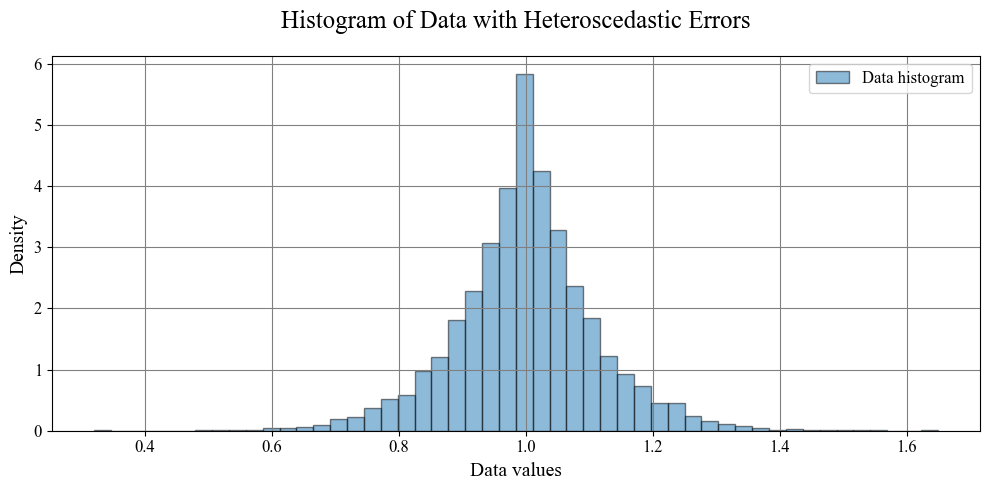

In [5]:
plt.hist(visualize, bins=50, density=True, alpha=0.5, histtype='barstacked', edgecolor='black', label='Data histogram');
plt.xlabel('Data values')
plt.ylabel('Density')
plt.title('Histogram of Data with Heteroscedastic Errors')
plt.legend()

## Bayesian Approach

In [6]:
errors = abs(np.random.normal(err_mean, err_sigm, 10))
data = np.random.normal(loc=true_mu, scale=errors, size=10)

In [60]:
from astroML.plotting.mcmc import convert_to_stdev

# Set prior bounds
mu_min, mu_max = -3, 5
sigma_min, sigma_max = 0.01, 5

def prior(mu, sigma):
    """Uniform prior in mu and log-uniform in sigma"""
    prior_val = np.zeros_like(mu)
    mask = (mu > mu_min) & (mu < mu_max) & (sigma > sigma_min) & (sigma < sigma_max)
    prior_val[mask] = 1 / (mu_max - mu_min) * np.log(sigma_max / sigma_min)
    return prior_val

def prior2(mu, sigma):
    """Gaussian prior in mu and Jeffreys prior in sigma"""
    mu0 = 1.0
    sigma0 = 1.0
    prior_mu = (1 / (np.sqrt(2 * np.pi) * sigma0)) * np.exp(-0.5 * ((mu - mu0) / sigma0)**2)
    prior_sigma = 1 / sigma
    # Avoid division by zero or invalid values
    prior_sigma = np.where((sigma > 0), prior_sigma, 0)
    return prior_mu * prior_sigma


def likelihood(mu, sigma, xi, ei):
    """Likelihood for Gaussian data with heteroscedastic errors"""
    s2_e2 = sigma**2 + ei[:, np.newaxis, np.newaxis]**2
    norm = np.sqrt(2 * np.pi * s2_e2)
    exp_term = np.exp(-0.5 * ((xi[:, np.newaxis, np.newaxis] - mu)**2 / s2_e2))
    return np.prod(exp_term / norm, axis=0)  # shape (70, 70)

def posterior(mu, sigma, xi, ei, prior):
    """Posterior = prior × likelihood"""
    return prior(mu, sigma) * likelihood(mu, sigma, xi, ei)

In [52]:
#------------------------------------------------------------
# Simulate data
mu_true = 1.
sigma_true = 1.
N = 10
ei = 3 * np.random.random(N)
xi = np.random.normal(mu_true, np.sqrt(sigma_true**2 + ei**2))

# Parameter grid
sigma = np.linspace(0.01, 5, 70)
mu = np.linspace(-3, 5, 70)
mu_grid, sigma_grid = np.meshgrid(mu, sigma)  # shape (70, 70)

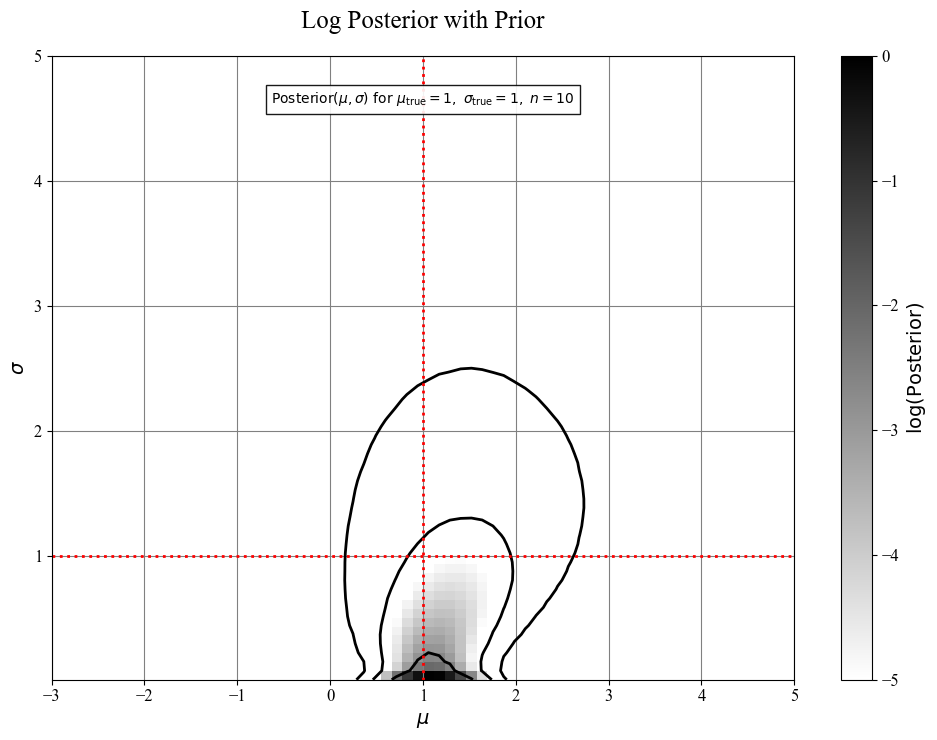

In [61]:
# Compute posterior
post = posterior(mu_grid, sigma_grid, xi, ei, prior2)
log_post = np.log(post)
log_post[np.isnan(log_post)] = -np.inf
log_post -= np.nanmax(log_post)

#------------------------------------------------------------
# Plotting
fig = plt.figure(figsize=(10, 7.5))
plt.imshow(log_post, origin='lower',
           extent=(mu[0], mu[-1], sigma[0], sigma[-1]),
           cmap=plt.cm.binary,
           aspect='auto')
plt.colorbar().set_label(r'$\log(\mathrm{Posterior})$')
plt.clim(-5, 0)

plt.text(0.5, 0.93,
         (r'$\mathrm{Posterior}(\mu,\sigma)\ \mathrm{for}\ \mu_{\rm true}=1,\ '
          r'\sigma_{\rm true}=1,\ n=10$'),
         bbox=dict(ec='k', fc='w', alpha=0.9),
         ha='center', va='center', transform=plt.gca().transAxes)

plt.contour(mu, sigma, convert_to_stdev(log_post),
            levels=(0.683, 0.955, 0.997),
            colors='k')

plt.axhline(sigma_true, c='red', ls='dotted')
plt.axvline(mu_true, c='red', ls='dotted')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.title("Log Posterior with Prior")
plt.show()

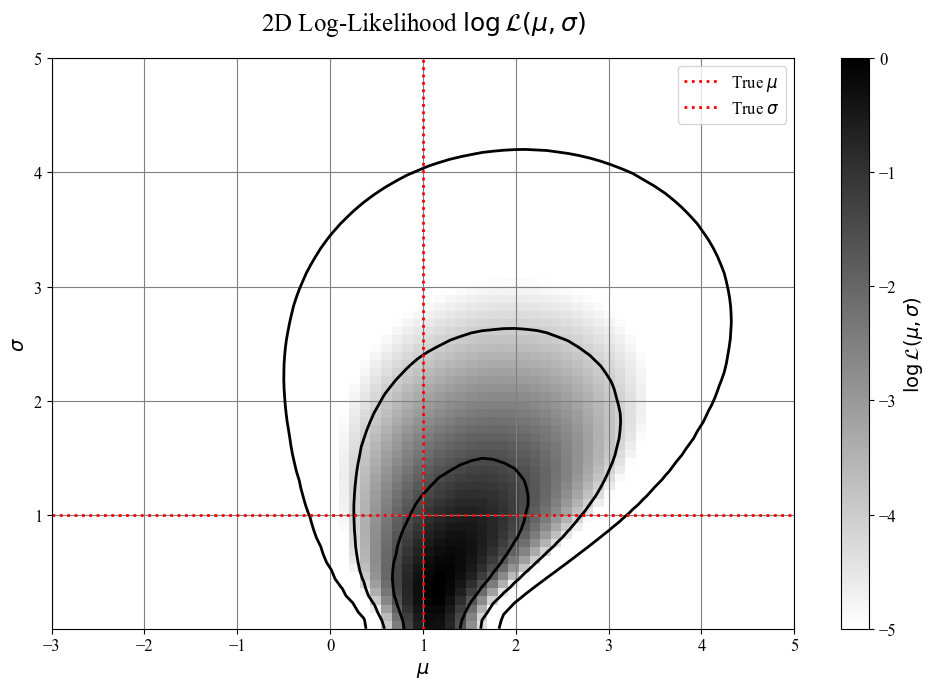

In [62]:
# Log-likelihood function
def gaussgauss_logL(xi, ei, mu, sigma):
    """Gaussian likelihood with heteroscedastic Gaussian errors"""
    ndim = len(np.broadcast(sigma, mu).shape)

    xi = xi.reshape(xi.shape + tuple(ndim * [1]))
    ei = ei.reshape(ei.shape + tuple(ndim * [1]))

    s2_e2 = sigma**2 + ei**2
    return -0.5 * np.sum(np.log(s2_e2) + (xi - mu)**2 / s2_e2, axis=0)

# Compute log-likelihood grid
logL = gaussgauss_logL(xi, ei, mu_grid, sigma_grid)
logL -= np.max(logL)  # normalize for stability

# Plot
plt.figure(figsize=(10, 7))
plt.imshow(logL, origin='lower',
           extent=(mu[0], mu[-1], sigma[0], sigma[-1]),
           aspect='auto', cmap='binary')
plt.colorbar(label=r'$\log \mathcal{L}(\mu, \sigma)$')
plt.clim(-5, 0)

# Contours at 1σ, 2σ, 3σ equivalent confidence regions
plt.contour(mu, sigma, convert_to_stdev(logL),
            levels=[0.683, 0.955, 0.997], colors='black')

# True values
plt.axvline(mu_true, color='red', linestyle='dotted', label=r'True $\mu$')
plt.axhline(sigma_true, color='red', linestyle='dotted', label=r'True $\sigma$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.title(r'2D Log-Likelihood $\log \mathcal{L}(\mu, \sigma)$')
plt.legend()
plt.tight_layout()
plt.show()


In [63]:
# ---- compute marginal posterior over mu ----
posterior_grid = posterior(mu_grid, sigma_grid, xi, ei, prior)

# Integrate out sigma
marginal_mu = np.trapezoid(posterior_grid, sigma, axis=0)

# Normalize
marginal_mu /= np.trapezoid(marginal_mu, mu)

# ---- compute marginal posterior over mu ----
posterior_grid2 = posterior(mu_grid, sigma_grid, xi, ei, prior2)

# Integrate out sigma
marginal_mu2 = np.trapezoid(posterior_grid, sigma, axis=0)

# Normalize
marginal_mu2 /= np.trapezoid(marginal_mu, mu)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ricca\AppData\Local\Temp\ipykernel_5448\437748646.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Marginal Posterior of $\mu$')
C:\Users\ricca\AppData\Local\Temp\ipykernel_5448\437748646.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Marginal Posterior of $\mu$')


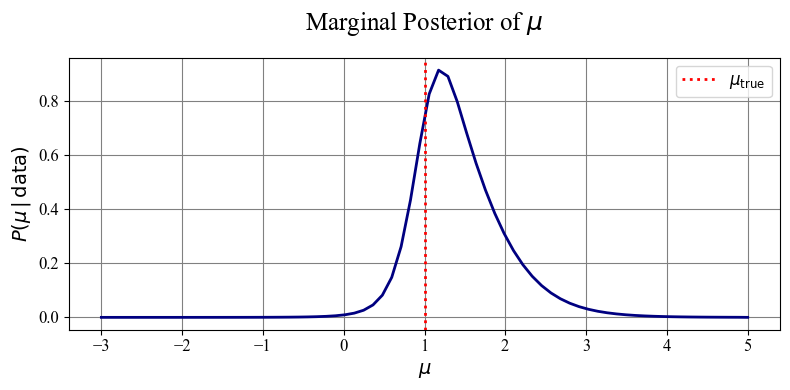

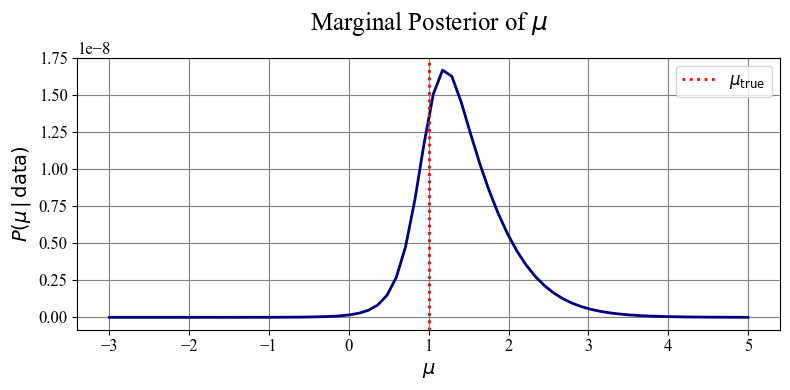

In [64]:
# ---- plot marginal posterior of mu ----
plt.figure(figsize=(8, 4))
plt.plot(mu, marginal_mu, color='navy')
plt.axvline(mu_true, color='red', linestyle='dotted', label=r'$\mu_\mathrm{true}$')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$P(\mu\,|\,\mathrm{data})$')
plt.title('Marginal Posterior of $\mu$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- plot marginal posterior of mu ----
plt.figure(figsize=(8, 4))
plt.plot(mu, marginal_mu2, color='navy')
plt.axvline(mu_true, color='red', linestyle='dotted', label=r'$\mu_\mathrm{true}$')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$P(\mu\,|\,\mathrm{data})$')
plt.title('Marginal Posterior of $\mu$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
